In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.random_search import RandomLineSearch
from converters.tile.bin_1d import make_1d_bin_palette
from image.processing import DITHER_MODES

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 9)[0]]
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]

def make_converter(params: Params):
    return RandomLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        generations=500,
        **params.converter_args)

Min: 0.0123 | Max: 0.0866 | Mean: 0.0461 | Std: 0.0221
Min: 0.0076 | Max: 0.0847 | Mean: 0.0454 | Std: 0.0276
Min: -0.0032 | Max: 0.0730 | Mean: 0.0397 | Std: 0.0233
Min: 0.0088 | Max: 0.0734 | Mean: 0.0410 | Std: 0.0191
Min: 0.0158 | Max: 0.0610 | Mean: 0.0353 | Std: 0.0153


C:\Users\wojte\AppData\Local\Temp\ipykernel_18320\2815104393.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


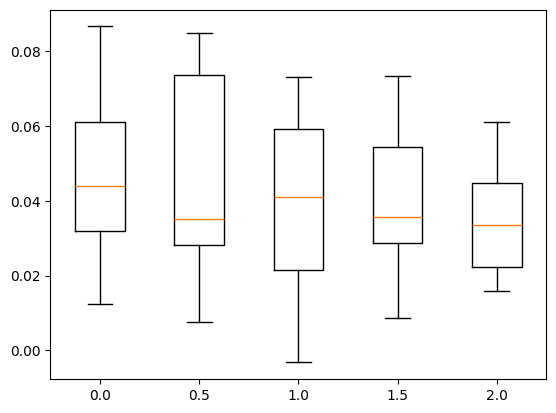

In [2]:
# edge enhancement

edge_enhancement_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.FS,
                         'enhance_edges': e}),
        edge_enhancement_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in edge_enhancement_vals])
plt.show()

In [3]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = RandomLineSearch(symbols=SYMBOLS,
                             font=FONT,
                             generations=500)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img,
                         enhance_edges=0.4,
                         find_edges=0.8,
                         quantize_colors=2, dither=DITHER_MODES.FS)
    font_height_px = FONT_SIZE * 1.333
    font_width_px = FONT_SIZE * 0.5
    scale_h = MAX_HEIGHT * font_height_px / img.height
    scale_w = MAX_WIDTH * font_width_px / img.width
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    results.append(converter.process_image(img))

print_gallery(results, 2)

---------------------------------------------------------------------
 | ^E/ED`/DN^yE^Ly/EDNLE//^DDEDLy | LND-NLNLND^N-NyyNDNNN/^L-EDENE | 
 | E/^EL-EyEEyE``LE-L^EyDEEDy`DL` | ^E-yD/NNLLED-DyEEED`^DEE/E`LDN | 
 | ELEN-^D/N/`D/EyLDEE`EED/L^/-Dy | ^/DDN^DENDNDLyN`yD-DE-E-^NyD-/ | 
 | DyyDDELNy//ED^^y^DEEDD^/LLEyD` | LD^DEDDEE/NE/EL^`yyE//-N^ENDLE | 
 | N^/D-NyDLDEL/E^DDLLyDDLD/LE/ED | EEN-`ENENNyLyDN--LyENyDDEE`yyD | 
 | yELLEL^/EE`LyDELyDDyLEELE^ND-E | yD/yENDyENNE^LDEL^//EyyED^NyE/ | 
 | yN`LNLND/yEDEN-NEELE`NE^LND^LD | LEDDE-DLD-DDEE`D^NN/DyLNNyDENE | 
 | E^Ny-NNNEED/EyD/E`LEDyD/DEy/DL | LNNy/L/DyENDDDyEyLyLN/DE^y^EyE | 
 | NNNE`yDDDE`EENEL-/DEyNNLE^NDN^ | LE/NNN/NEDDDL^yNy/D/`L^^EL/NyL | 
---------------------------------------------------------------------
 | -NLEEED^ELD/yELNNE`LNyEL/LE//y | --LD`/`/`-ELL-^/ | 
 | DLLEE`E/DEN-EEN^EyyD-DEEDL/ED` | -EE`-`/-/^^`^``- | 
 | /yEEDD-E`EyDELEyDD^EE/-L`^^yDL | `--L-^L//E`LL``` | 
 | -E^/NyLNE^LDy/yDEEE/LELDLNN^N` | LL/`D-D-/D`^D``` | 
 | E/E